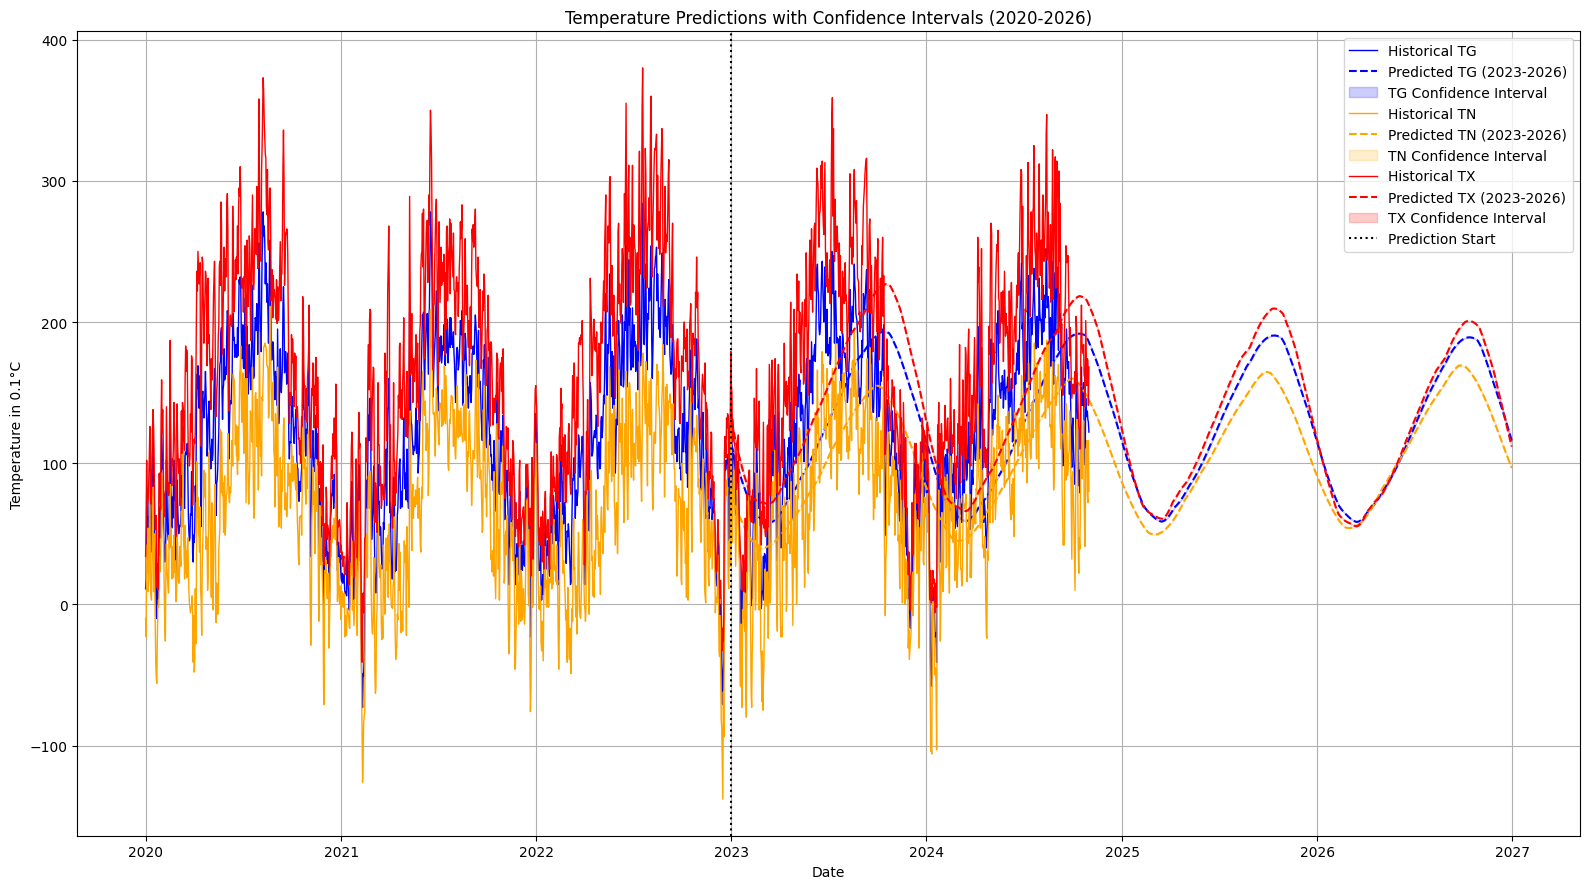

In [32]:
import pandas as pd
import numpy as np
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# File paths
file_tg_path = 'TG_SOUID121044.txt'
file_tn_path = 'TN_SOUID121045.txt'
file_tx_path = 'TX_SOUID121046.txt'

# Function to load and process data
def load_and_process(file_path, temp_col, quality_col):
    with open(file_path, 'r') as file:
        lines = file.readlines()

    # Identify data start
    data_start_index = next(i for i, line in enumerate(lines) if "SOUID" in line and "DATE" in line) + 1

    # Extract relevant data
    data_lines = lines[data_start_index:]
    data = []
    for line in data_lines:
        parts = line.split(",")
        if len(parts) >= 4:
            data.append([parts[0].strip(), parts[1].strip(), parts[2].strip(), parts[3].strip()])

    # Create DataFrame
    columns = ["SOUID", "DATE", temp_col, quality_col]
    df = pd.DataFrame(data, columns=columns)

    # Convert to appropriate types
    df[temp_col] = pd.to_numeric(df[temp_col], errors='coerce')
    df[quality_col] = pd.to_numeric(df[quality_col], errors='coerce')

    # Filter valid data
    df = df[df[quality_col] == 0]
    df["DATE"] = pd.to_datetime(df["DATE"], format='%Y%m%d')

    # Filter data from 2020 onwards
    df = df[df["DATE"] >= "2020-01-01"]
    return df

# Load datasets
tg_data = load_and_process(file_tg_path, "TG", "Q_TG")
tn_data = load_and_process(file_tn_path, "TN", "Q_TN")
tx_data = load_and_process(file_tx_path, "TX", "Q_TX")

# Combine datasets
combined_data = pd.merge(tg_data[["DATE", "TG"]], tn_data[["DATE", "TN"]], on="DATE")
combined_data = pd.merge(combined_data, tx_data[["DATE", "TX"]], on="DATE")

# Prepare for MLP fitting
X = (combined_data["DATE"] - pd.Timestamp("2023-11-01")).dt.days.values.reshape(-1, 1)

# Adding periodic features
X_periodic = np.hstack([
    X,
    np.sin(2 * np.pi * X / 365.25),  # Annual cycle
    np.cos(2 * np.pi * X / 365.25)
])

# Scale features
scaler_X = StandardScaler()
scaler_y = StandardScaler()
X_scaled = scaler_X.fit_transform(X_periodic)

# Initialize plot
plt.figure(figsize=(16, 9))

# Loop through each temperature variable
for variable, color in zip(["TG", "TN", "TX"], ["blue", "orange", "red"]):
    # Prepare data for the current variable
    y = combined_data[variable].values
    y_scaled = scaler_y.fit_transform(y.reshape(-1, 1)).ravel()

    # Train MLP
    mlp = MLPRegressor(hidden_layer_sizes=(50,), max_iter=5000, random_state=42)
    mlp.fit(X_scaled, y_scaled)

    # Historical predictions
    y_pred_scaled = mlp.predict(X_scaled)
    y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()

    # Residuals and error calculation
    residuals = y - scaler_y.inverse_transform(y_scaled.reshape(-1, 1)).ravel()
    std_dev = np.std(residuals)

    # Future predictions
    future_dates = pd.date_range(start="2023-01-01", end="2026-12-31")
    X_future = (future_dates - pd.Timestamp("2020-01-01")).days.values.reshape(-1, 1)
    X_future_periodic = np.hstack([
        X_future,
        np.sin(2 * np.pi * X_future / 365.25),
        np.cos(2 * np.pi * X_future / 365.25)
    ])
    X_future_scaled = scaler_X.transform(X_future_periodic)
    y_future_scaled = mlp.predict(X_future_scaled)
    y_future = scaler_y.inverse_transform(y_future_scaled.reshape(-1, 1)).ravel()

    # Upper and lower bounds
    upper_bound = y_future + std_dev
    lower_bound = y_future - std_dev

    # Plot historical and predicted data
    plt.plot(combined_data["DATE"], combined_data[variable], label=f"Historical {variable}", linestyle='-', linewidth=1, color=color)
    plt.plot(future_dates, y_future, label=f"Predicted {variable} (2023-2026)", linestyle='--', color=color)
    plt.fill_between(future_dates, lower_bound, upper_bound, color=color, alpha=0.2, label=f"{variable} Confidence Interval")

# Mark prediction start
plt.axvline(x=pd.Timestamp("2023-01-01"), color="black", linestyle=":", label="Prediction Start")

# Add titles and labels
plt.title("Temperature Predictions with Confidence Intervals (2020-2026)")
plt.xlabel("Date")
plt.ylabel("Temperature in 0.1°C")
plt.legend()
plt.grid(True)
plt.tight_layout()

# Show plot
plt.show()


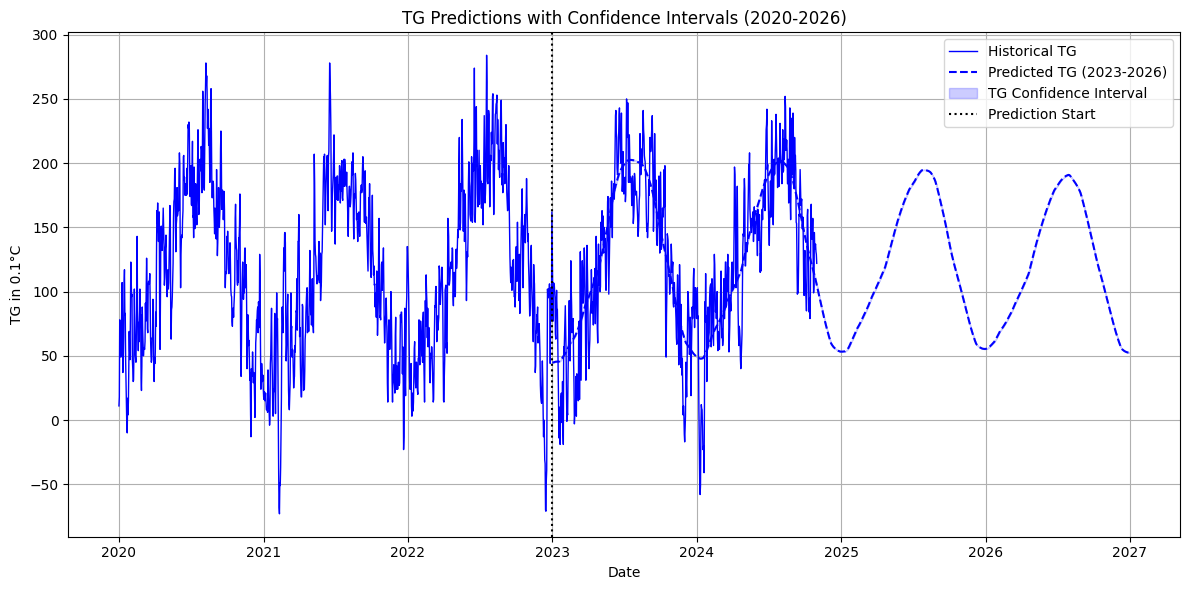

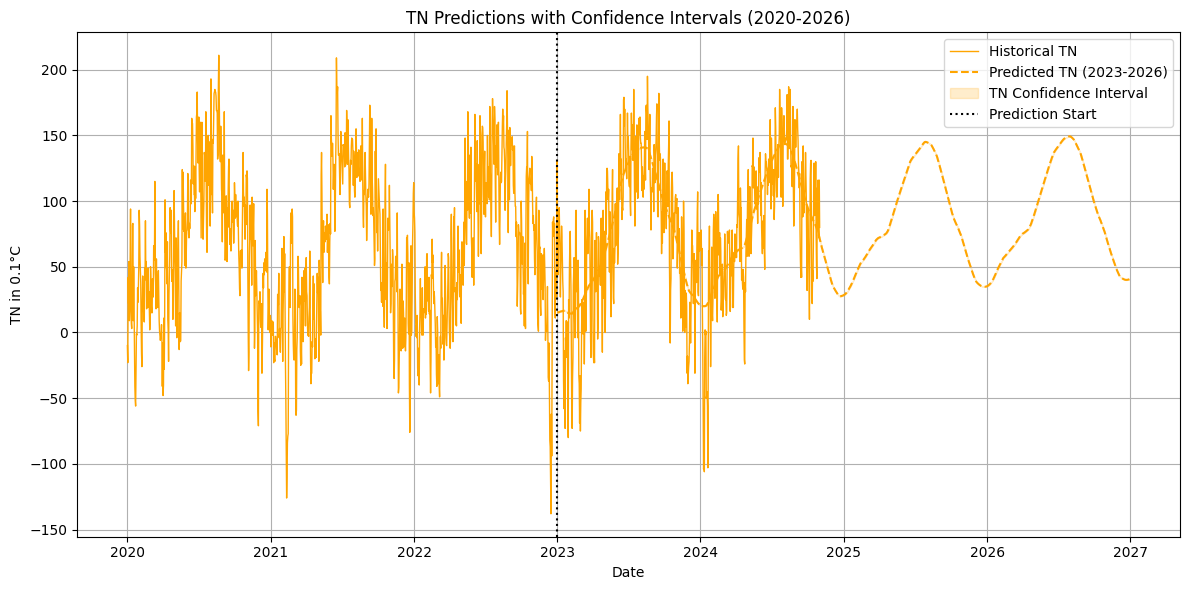

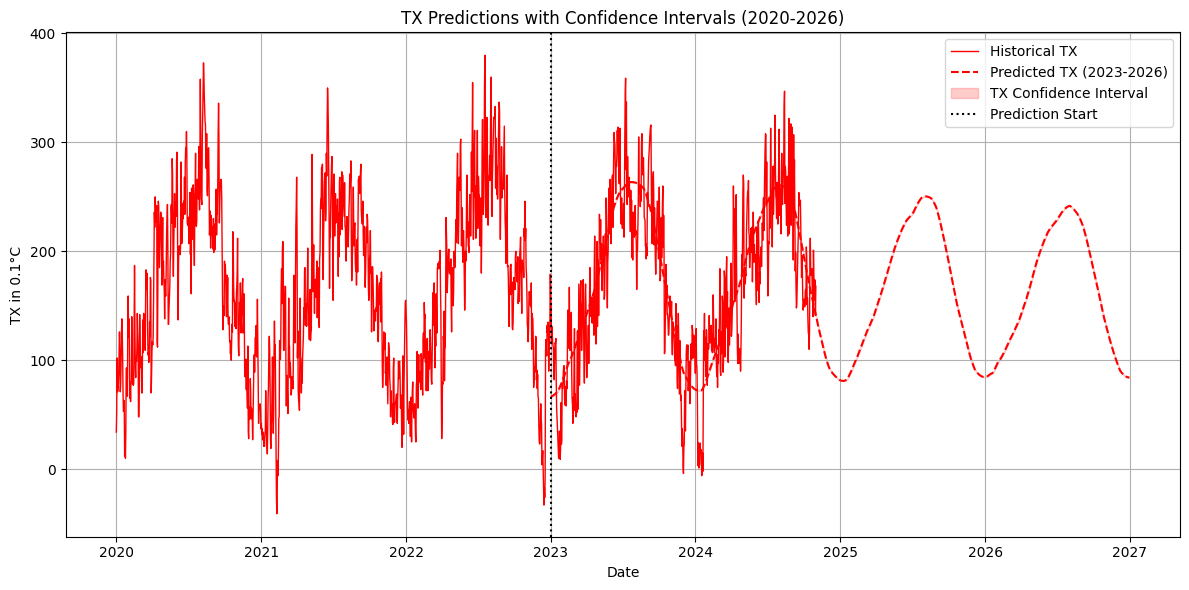

In [10]:
import pandas as pd
import numpy as np
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# File paths
file_tg_path = 'TG_SOUID121044.txt'
file_tn_path = 'TN_SOUID121045.txt'
file_tx_path = 'TX_SOUID121046.txt'

# Function to load and process data
def load_and_process(file_path, temp_col, quality_col):
    with open(file_path, 'r') as file:
        lines = file.readlines()

    # Identify data start
    data_start_index = next(i for i, line in enumerate(lines) if "SOUID" in line and "DATE" in line) + 1

    # Extract relevant data
    data_lines = lines[data_start_index:]
    data = []
    for line in data_lines:
        parts = line.split(",")
        if len(parts) >= 4:
            data.append([parts[0].strip(), parts[1].strip(), parts[2].strip(), parts[3].strip()])

    # Create DataFrame
    columns = ["SOUID", "DATE", temp_col, quality_col]
    df = pd.DataFrame(data, columns=columns)

    # Convert to appropriate types
    df[temp_col] = pd.to_numeric(df[temp_col], errors='coerce')
    df[quality_col] = pd.to_numeric(df[quality_col], errors='coerce')

    # Filter valid data
    df = df[df[quality_col] == 0]
    df["DATE"] = pd.to_datetime(df["DATE"], format='%Y%m%d')

    # Filter data from 2020 onwards
    df = df[df["DATE"] >= "2020-01-01"]
    return df

# Load datasets
tg_data = load_and_process(file_tg_path, "TG", "Q_TG")
tn_data = load_and_process(file_tn_path, "TN", "Q_TN")
tx_data = load_and_process(file_tx_path, "TX", "Q_TX")

# Combine datasets
combined_data = pd.merge(tg_data[["DATE", "TG"]], tn_data[["DATE", "TN"]], on="DATE")
combined_data = pd.merge(combined_data, tx_data[["DATE", "TX"]], on="DATE")

# Prepare for MLP fitting
X = (combined_data["DATE"] - pd.Timestamp("2020-01-01")).dt.days.values.reshape(-1, 1)

# Adding periodic features
X_periodic = np.hstack([
    X,
    np.sin(2 * np.pi * X / 365.25),  # Annual cycle
    np.cos(2 * np.pi * X / 365.25)
])

# Scale features
scaler_X = StandardScaler()
scaler_y = StandardScaler()
X_scaled = scaler_X.fit_transform(X_periodic)

# Loop through each temperature variable
for variable, color in zip(["TG", "TN", "TX"], ["blue", "orange", "red"]):
    # Prepare data for the current variable
    y = combined_data[variable].values
    y_scaled = scaler_y.fit_transform(y.reshape(-1, 1)).ravel()

    # Train MLP
    mlp = MLPRegressor(hidden_layer_sizes=(50,), max_iter=5000, random_state=42)
    mlp.fit(X_scaled, y_scaled)

    # Historical predictions
    y_pred_scaled = mlp.predict(X_scaled)
    y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()

    # Residuals and error calculation
    residuals = y - scaler_y.inverse_transform(y_scaled.reshape(-1, 1)).ravel()
    std_dev = np.std(residuals)

    # Future predictions
    future_dates = pd.date_range(start="2023-01-01", end="2026-12-31")
    X_future = (future_dates - pd.Timestamp("2020-01-01")).days.values.reshape(-1, 1)
    X_future_periodic = np.hstack([
        X_future,
        np.sin(2 * np.pi * X_future / 365.25),
        np.cos(2 * np.pi * X_future / 365.25)
    ])
    X_future_scaled = scaler_X.transform(X_future_periodic)
    y_future_scaled = mlp.predict(X_future_scaled)
    y_future = scaler_y.inverse_transform(y_future_scaled.reshape(-1, 1)).ravel()

    # Upper and lower bounds
    upper_bound = y_future + std_dev
    lower_bound = y_future - std_dev

    # Create individual plots
    plt.figure(figsize=(12, 6))
    plt.plot(combined_data["DATE"], combined_data[variable], label=f"Historical {variable}", linestyle='-', linewidth=1, color=color)
    plt.plot(future_dates, y_future, label=f"Predicted {variable} (2023-2026)", linestyle='--', color=color)
    plt.fill_between(future_dates, lower_bound, upper_bound, color=color, alpha=0.2, label=f"{variable} Confidence Interval")
    plt.axvline(x=pd.Timestamp("2023-01-01"), color="black", linestyle=":", label="Prediction Start")
    plt.title(f"{variable} Predictions with Confidence Intervals (2020-2026)")
    plt.xlabel("Date")
    plt.ylabel(f"{variable} in 0.1°C")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


/var/folders/31/nj5p89nx2gg_nrh13dqr10y80000gn/T/ipykernel_69952/1592885128.py:118: RuntimeWarning: divide by zero encountered in divide
  error_rate = np.mean(np.abs(real_y - real_y_pred) / real_y) * 100


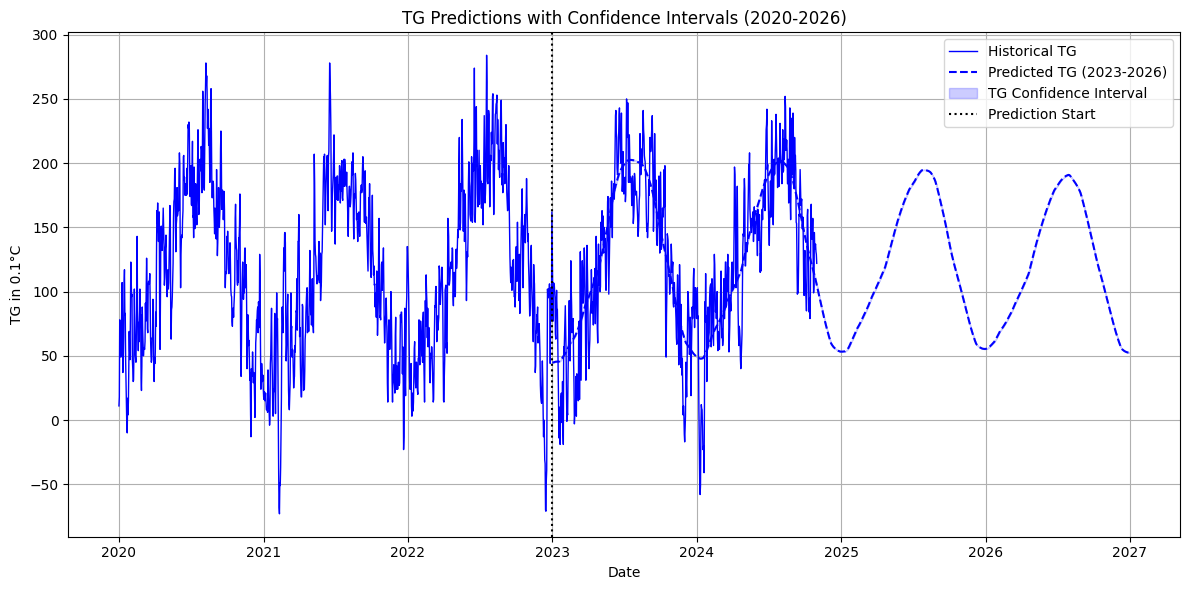

/var/folders/31/nj5p89nx2gg_nrh13dqr10y80000gn/T/ipykernel_69952/1592885128.py:118: RuntimeWarning: divide by zero encountered in divide
  error_rate = np.mean(np.abs(real_y - real_y_pred) / real_y) * 100


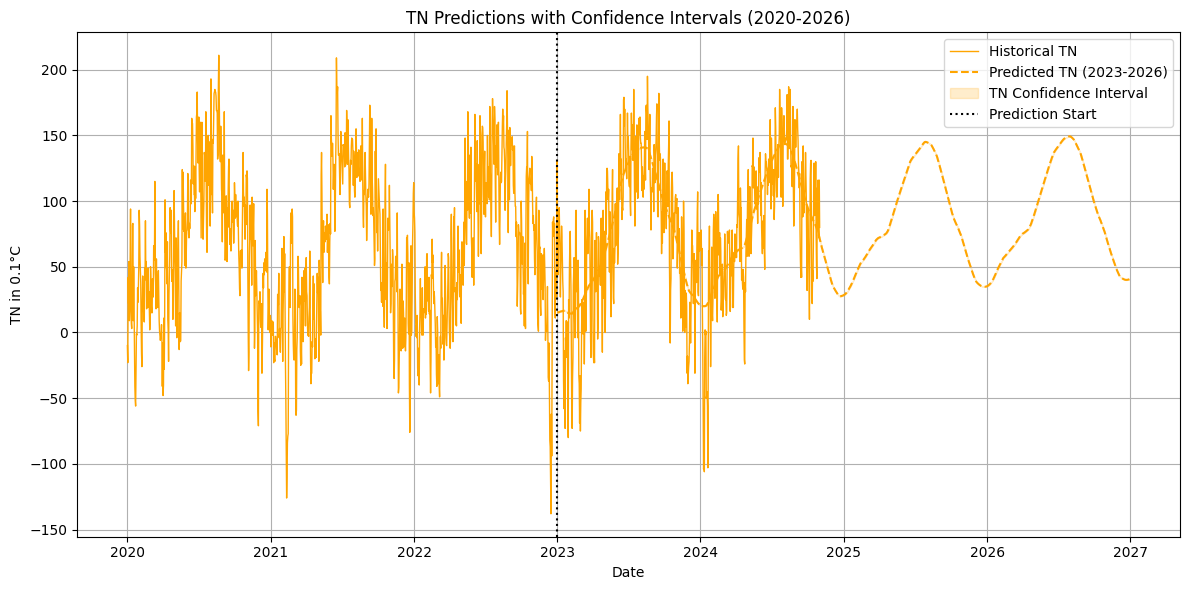

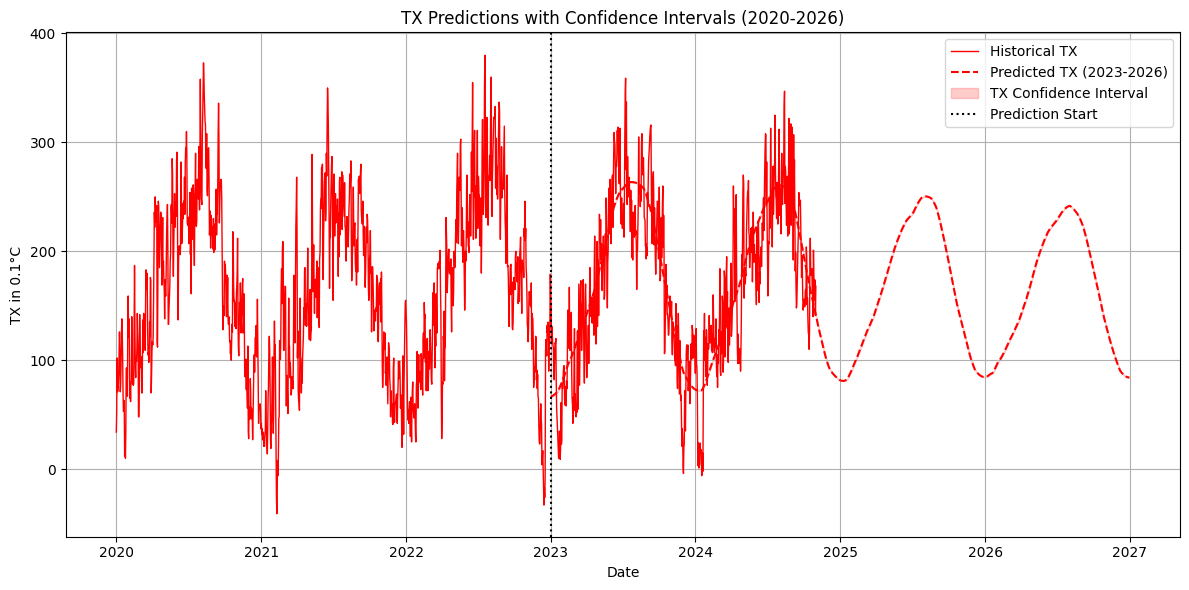

Error rate for TG between 2022 and 2024: inf%
Error rate for TN between 2022 and 2024: inf%
Error rate for TX between 2022 and 2024: 31.64%


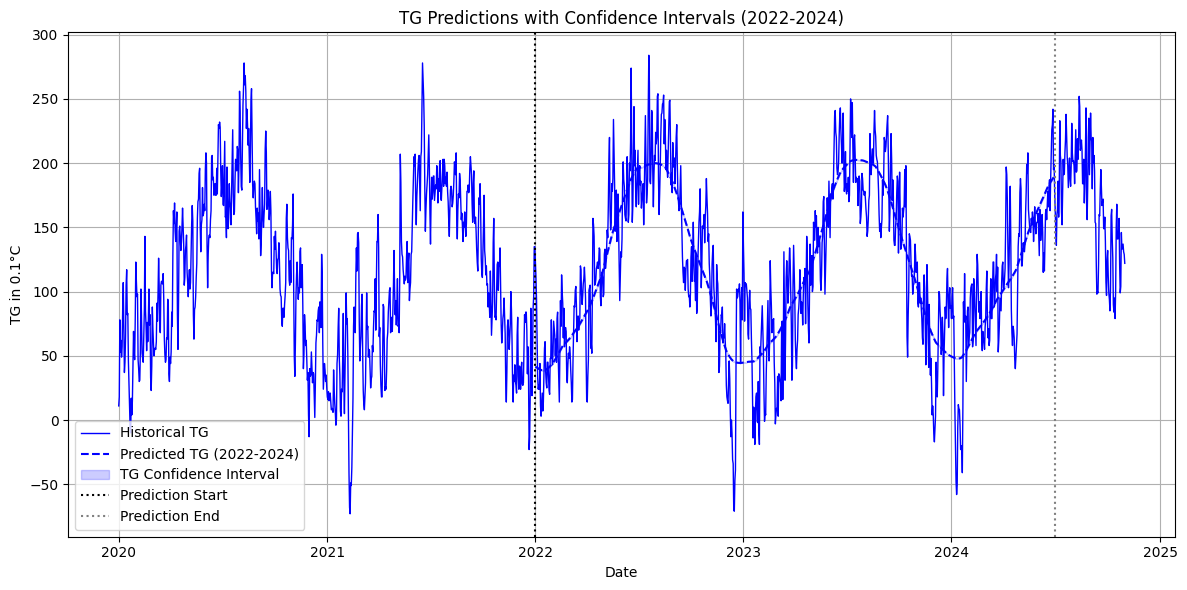

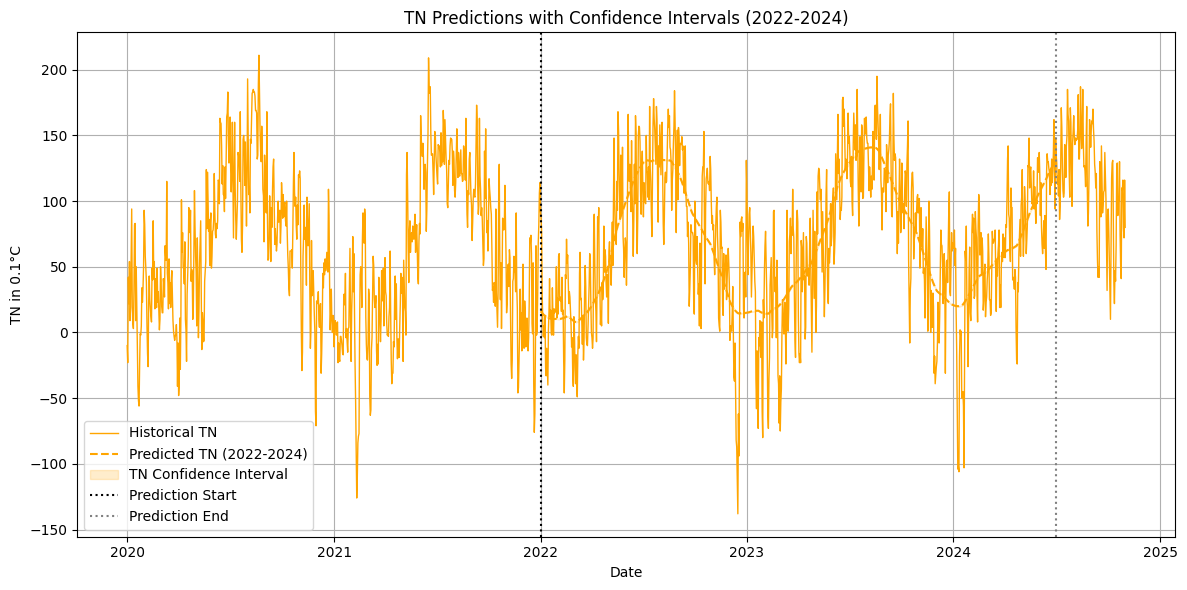

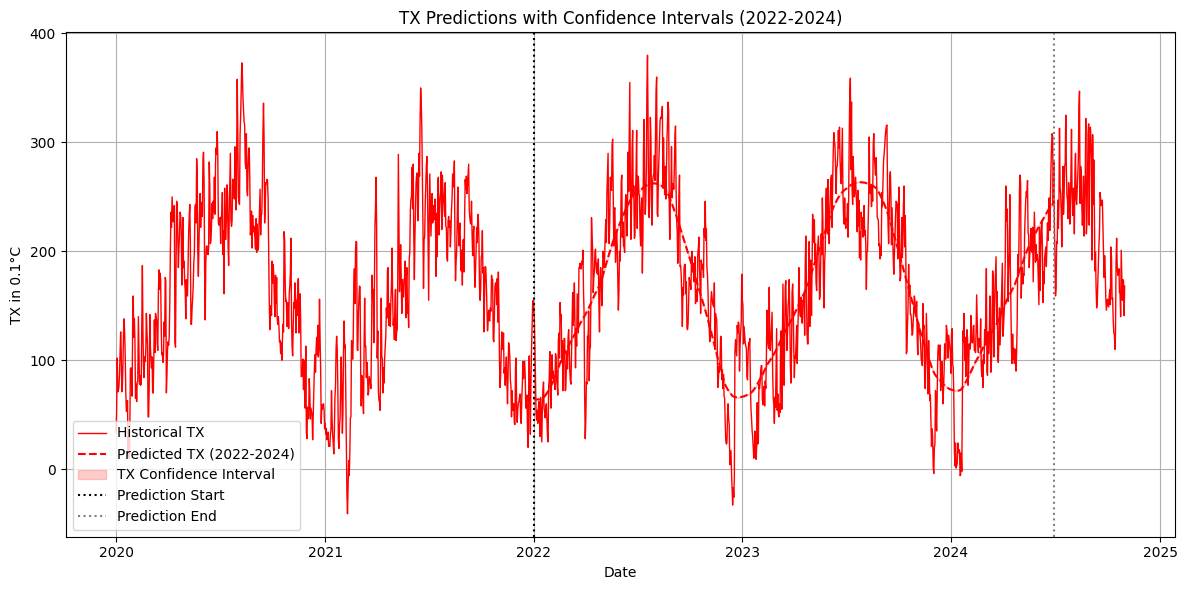

Error rate for TG between 2022 and 2023: 20.77%
Error rate for TN between 2022 and 2023: 34.22%
Error rate for TX between 2022 and 2023: 33.89%
chi-sq: {'TG': {'Chi2 Statistic': np.float64(0.1258267036675982), 'p-value': np.float64(1.0)}, 'TN': {'Chi2 Statistic': np.float64(0.5353634115474026), 'p-value': np.float64(1.0)}, 'TX': {'Chi2 Statistic': np.float64(0.07201197605615084), 'p-value': np.float64(1.0)}}
{'TG': np.float64(0.20234583471679035), 'TN': np.float64(-2.5510826248407756), 'TX': np.float64(0.7510930263021065)}


In [ ]:
import pandas as pd
import numpy as np
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# File paths
file_tg_path = 'TG_SOUID121044.txt'
file_tn_path = 'TN_SOUID121045.txt'
file_tx_path = 'TX_SOUID121046.txt'

# Function to load and process data
def load_and_process(file_path, temp_col, quality_col):
    with open(file_path, 'r') as file:
        lines = file.readlines()

    # Identify data start
    data_start_index = next(i for i, line in enumerate(lines) if "SOUID" in line and "DATE" in line) + 1

    # Extract relevant data
    data_lines = lines[data_start_index:]
    data = []
    for line in data_lines:
        parts = line.split(",")
        if len(parts) >= 4:
            data.append([parts[0].strip(), parts[1].strip(), parts[2].strip(), parts[3].strip()])

    # Create DataFrame
    columns = ["SOUID", "DATE", temp_col, quality_col]
    df = pd.DataFrame(data, columns=columns)

    # Convert to appropriate types
    df[temp_col] = pd.to_numeric(df[temp_col], errors='coerce')
    df[quality_col] = pd.to_numeric(df[quality_col], errors='coerce')

    # Filter valid data
    df = df[df[quality_col] == 0]
    df["DATE"] = pd.to_datetime(df["DATE"], format='%Y%m%d')

    # Filter data from 2020 onwards
    df = df[df["DATE"] >= "2020-01-01"]
    return df

# Load datasets
tg_data = load_and_process(file_tg_path, "TG", "Q_TG")
tn_data = load_and_process(file_tn_path, "TN", "Q_TN")
tx_data = load_and_process(file_tx_path, "TX", "Q_TX")

# Combine datasets
combined_data = pd.merge(tg_data[["DATE", "TG"]], tn_data[["DATE", "TN"]], on="DATE")
combined_data = pd.merge(combined_data, tx_data[["DATE", "TX"]], on="DATE")

# Prepare for MLP fitting
X = (combined_data["DATE"] - pd.Timestamp("2020-01-01")).dt.days.values.reshape(-1, 1)

# Adding periodic features
X_periodic = np.hstack([
    X,
    np.sin(2 * np.pi * X / 365.25),  # Annual cycle
    np.cos(2 * np.pi * X / 365.25)
])

# Scale features
scaler_X = StandardScaler()
scaler_y = StandardScaler()
X_scaled = scaler_X.fit_transform(X_periodic)

# Define prediction start and end dates
prediction_start = pd.Timestamp("2022-01-01")
prediction_end = pd.Timestamp("2024-06-30")
future_dates = pd.date_range(start=prediction_start, end=prediction_end)
X_future = (future_dates - pd.Timestamp("2020-01-01")).days.values.reshape(-1, 1)
X_future_periodic = np.hstack([
    X_future,
    np.sin(2 * np.pi * X_future / 365.25),
    np.cos(2 * np.pi * X_future / 365.25)
])
X_future_scaled = scaler_X.transform(X_future_periodic)

# Loop through each temperature variable
error_rates = {}
for variable, color in zip(["TG", "TN", "TX"], ["blue", "orange", "red"]):
    # Prepare data for the current variable
    y = combined_data[variable].values
    y_scaled = scaler_y.fit_transform(y.reshape(-1, 1)).ravel()

    # Train MLP
    mlp = MLPRegressor(hidden_layer_sizes=(50,), max_iter=5000, random_state=42)
    mlp.fit(X_scaled, y_scaled)

    # Historical predictions
    y_pred_scaled = mlp.predict(X_scaled)
    y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()

    # Residuals and error calculation
    residuals = y - scaler_y.inverse_transform(y_scaled.reshape(-1, 1)).ravel()
    std_dev = np.std(residuals)

    # Future predictions
    y_future_scaled = mlp.predict(X_future_scaled)
    y_future = scaler_y.inverse_transform(y_future_scaled.reshape(-1, 1)).ravel()

    # Upper and lower bounds
    upper_bound = y_future + std_dev
    lower_bound = y_future - std_dev

    # Calculate error rate between 2022 and 2024
    actual_data = combined_data[(combined_data["DATE"] >= prediction_start) & (combined_data["DATE"] <= prediction_end)]
    actual_values = actual_data[variable].values
    predicted_values = y_future[:len(actual_values)]

    # Avoid division by zero for error calculation
    valid_indices = actual_values != 0
    error_rate = np.mean(np.abs(actual_values[valid_indices] - predicted_values[valid_indices]) / actual_values[valid_indices]) * 100
    error_rates[variable] = error_rate


    # Create individual plots
    plt.figure(figsize=(12, 6))
    plt.plot(combined_data["DATE"], combined_data[variable], label=f"Historical {variable}", linestyle='-', linewidth=1, color=color)
    plt.plot(future_dates, y_future, label=f"Predicted {variable} (2022-2024)", linestyle='--', color=color)
    plt.fill_between(future_dates, lower_bound, upper_bound, color=color, alpha=0.2, label=f"{variable} Confidence Interval")
    plt.axvline(x=prediction_start, color="black", linestyle=":", label="Prediction Start")
    plt.axvline(x=prediction_end, color="grey", linestyle=":", label="Prediction End")
    plt.title(f"{variable} Predictions with Confidence Intervals (2022-2024)")
    plt.xlabel("Date")
    plt.ylabel(f"{variable} in 0.1°C")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Print error rates
for variable, error_rate in error_rates.items():
    print(f"Error rate for {variable} between 2022 and 2023: {error_rate:.2f}%")



from scipy.stats import chisquare

# Chi-square test results for each dataset
chi_square_results = {}

for variable in ["TG", "TN", "TX"]:
    # Observed values (2022-2024 actual data)
    actual_data = combined_data[(combined_data["DATE"] >= prediction_start) & (combined_data["DATE"] <= prediction_end)]
    observed = actual_data[variable].values

    # Predicted values (2022-2024 predictions)
    predicted = y_future[:len(observed)]

    # Ensure no zero or negative predicted values to avoid errors
    if np.any(predicted <= 0):
        print(f"Skipping {variable} due to invalid predicted values (<= 0).")
        continue

    # Normalize observed and predicted frequencies
    observed_normalized = observed / np.sum(observed)
    predicted_normalized = predicted / np.sum(predicted)

    # Chi-square test
    chi2_stat, p_value = chisquare(f_obs=observed_normalized, f_exp=predicted_normalized)
    chi_square_results[variable] = {"Chi2 Statistic": chi2_stat, "p-value": p_value}

# Display the results
print('chi-sq:',chi_square_results)

# R^2 Calculation
r_squared_results = {}

for variable in ["TG", "TN", "TX"]:
    # Observed values (2022-2024 actual data)
    actual_data = combined_data[(combined_data["DATE"] >= prediction_start) & (combined_data["DATE"] <= prediction_end)]
    observed = actual_data[variable].values

    # Predicted values (2022-2024 predictions)
    predicted = y_future[:len(observed)]

    # Calculate R^2
    ss_residual = np.sum((observed - predicted) ** 2)  # Residual sum of squares
    ss_total = np.sum((observed - np.mean(observed)) ** 2)  # Total sum of squares
    r_squared = 1 - (ss_residual / ss_total)
    r_squared_results[variable] = r_squared

# Display R^2 results
print(r_squared_results)


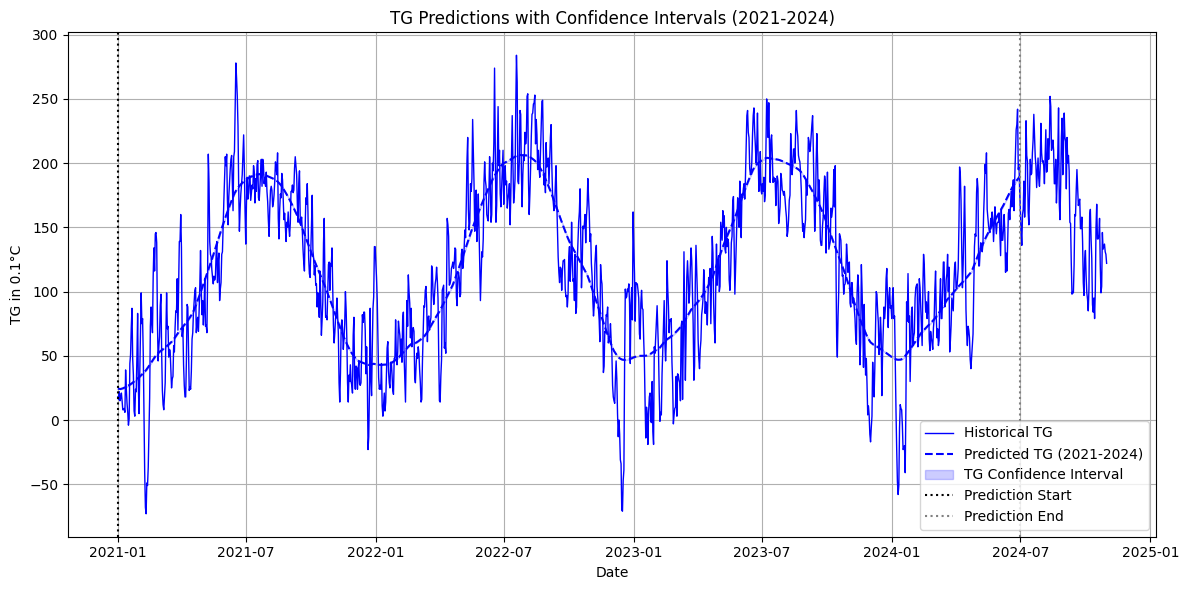

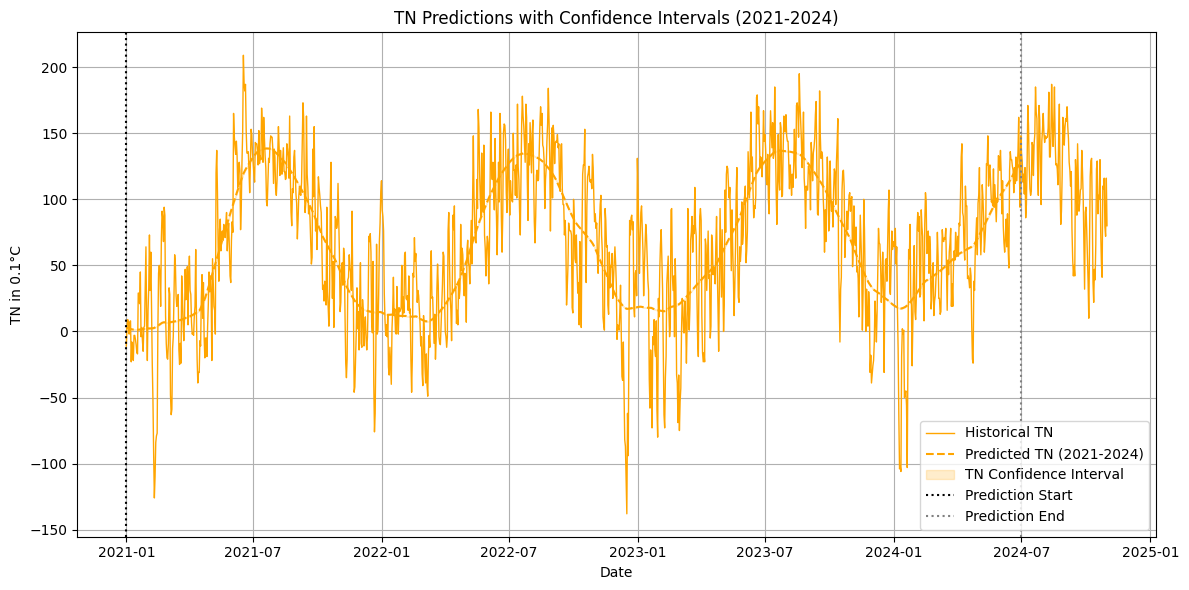

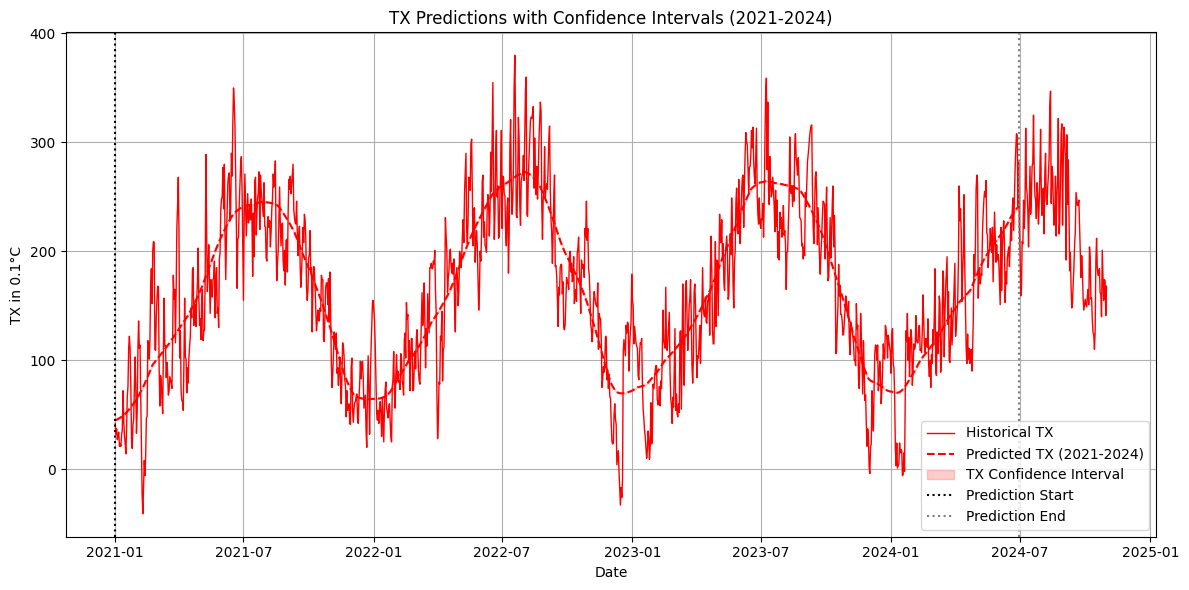

Error rate for TG between 2021 and 2024: 27.51%
Error rate for TN between 2021 and 2024: 20.35%
Error rate for TX between 2021 and 2024: 30.09%
chi sqr: {'TG': {'Chi2 Statistic': np.float64(0.13048869703098645), 'p-value': np.float64(1.0)}, 'TN': {'Chi2 Statistic': np.float64(0.5875433067773491), 'p-value': np.float64(1.0)}, 'TX': {'Chi2 Statistic': np.float64(0.07358548757475955), 'p-value': np.float64(1.0)}}
r_sqr: {'TG': np.float64(0.18578840107930006), 'TN': np.float64(-2.3960582472963825), 'TX': np.float64(0.7598568202961673)}


In [29]:
import pandas as pd
import numpy as np
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# File paths
file_tg_path = 'TG_SOUID121044.txt'
file_tn_path = 'TN_SOUID121045.txt'
file_tx_path = 'TX_SOUID121046.txt'

# Function to load and process data
def load_and_process(file_path, temp_col, quality_col):
    with open(file_path, 'r') as file:
        lines = file.readlines()

    # Identify data start
    data_start_index = next(i for i, line in enumerate(lines) if "SOUID" in line and "DATE" in line) + 1

    # Extract relevant data
    data_lines = lines[data_start_index:]
    data = []
    for line in data_lines:
        parts = line.split(",")
        if len(parts) >= 4:
            data.append([parts[0].strip(), parts[1].strip(), parts[2].strip(), parts[3].strip()])

    # Create DataFrame
    columns = ["SOUID", "DATE", temp_col, quality_col]
    df = pd.DataFrame(data, columns=columns)

    # Convert to appropriate types
    df[temp_col] = pd.to_numeric(df[temp_col], errors='coerce')
    df[quality_col] = pd.to_numeric(df[quality_col], errors='coerce')

    # Filter valid data
    df = df[df[quality_col] == 0]
    df["DATE"] = pd.to_datetime(df["DATE"], format='%Y%m%d')

    # Filter data from 2020 onwards
    df = df[df["DATE"] >= "2021-01-01"]
    return df

# Load datasets
tg_data = load_and_process(file_tg_path, "TG", "Q_TG")
tn_data = load_and_process(file_tn_path, "TN", "Q_TN")
tx_data = load_and_process(file_tx_path, "TX", "Q_TX")

# Combine datasets
combined_data = pd.merge(tg_data[["DATE", "TG"]], tn_data[["DATE", "TN"]], on="DATE")
combined_data = pd.merge(combined_data, tx_data[["DATE", "TX"]], on="DATE")

# Prepare for MLP fitting
X = (combined_data["DATE"] - pd.Timestamp("2021-01-01")).dt.days.values.reshape(-1, 1)

# Adding periodic features
X_periodic = np.hstack([
    X,
    np.sin(2 * np.pi * X / 365.25),  # Annual cycle
    np.cos(2 * np.pi * X / 365.25)
])

# Scale features
scaler_X = StandardScaler()
scaler_y = StandardScaler()
X_scaled = scaler_X.fit_transform(X_periodic)

# Define prediction start and end dates
prediction_start = pd.Timestamp("2021-01-01")
prediction_end = pd.Timestamp("2024-06-30")
future_dates = pd.date_range(start=prediction_start, end=prediction_end)
X_future = (future_dates - pd.Timestamp("2021-01-01")).days.values.reshape(-1, 1)
X_future_periodic = np.hstack([
    X_future,
    np.sin(2 * np.pi * X_future / 365.25),
    np.cos(2 * np.pi * X_future / 365.25)
])
X_future_scaled = scaler_X.transform(X_future_periodic)

# Loop through each temperature variable
error_rates = {}
for variable, color in zip(["TG", "TN", "TX"], ["blue", "orange", "red"]):
    # Prepare data for the current variable
    y = combined_data[variable].values
    y_scaled = scaler_y.fit_transform(y.reshape(-1, 1)).ravel()

    # Train MLP
    mlp = MLPRegressor(hidden_layer_sizes=(50,), max_iter=5000, random_state=42)
    mlp.fit(X_scaled, y_scaled)

    # Historical predictions
    y_pred_scaled = mlp.predict(X_scaled)
    y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()

    # Residuals and error calculation
    residuals = y - scaler_y.inverse_transform(y_scaled.reshape(-1, 1)).ravel()
    std_dev = np.std(residuals)

    # Future predictions
    y_future_scaled = mlp.predict(X_future_scaled)
    y_future = scaler_y.inverse_transform(y_future_scaled.reshape(-1, 1)).ravel()

    # Upper and lower bounds
    upper_bound = y_future + std_dev
    lower_bound = y_future - std_dev

    # Calculate error rate between 2020 and 2024
    actual_data = combined_data[(combined_data["DATE"] >= prediction_start) & (combined_data["DATE"] <= prediction_end)]
    actual_values = actual_data[variable].values
    predicted_values = y_future[:len(actual_values)]

    # Avoid division by zero for error calculation
    valid_indices = actual_values != 0
    error_rate = np.mean(np.abs(actual_values[valid_indices] - predicted_values[valid_indices]) / actual_values[valid_indices]) * 100
    error_rates[variable] = error_rate


    # Create individual plots
    plt.figure(figsize=(12, 6))
    plt.plot(combined_data["DATE"], combined_data[variable], label=f"Historical {variable}", linestyle='-', linewidth=1, color=color)
    plt.plot(future_dates, y_future, label=f"Predicted {variable} (2021-2024)", linestyle='--', color=color)
    plt.fill_between(future_dates, lower_bound, upper_bound, color=color, alpha=0.2, label=f"{variable} Confidence Interval")
    plt.axvline(x=prediction_start, color="black", linestyle=":", label="Prediction Start")
    plt.axvline(x=prediction_end, color="grey", linestyle=":", label="Prediction End")
    plt.title(f"{variable} Predictions with Confidence Intervals (2021-2024)")
    plt.xlabel("Date")
    plt.ylabel(f"{variable} in 0.1°C")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Print error rates
for variable, error_rate in error_rates.items():
    print(f"Error rate for {variable} between 2021 and 2024: {error_rate:.2f}%")


from scipy.stats import chisquare

# Chi-square test results for each dataset
chi_square_results = {}

for variable in ["TG", "TN", "TX"]:
    # Observed values (2022-2024 actual data)
    actual_data = combined_data[(combined_data["DATE"] >= prediction_start) & (combined_data["DATE"] <= prediction_end)]
    observed = actual_data[variable].values

    # Predicted values (2022-2024 predictions)
    predicted = y_future[:len(observed)]

    # Ensure no zero or negative predicted values to avoid errors
    if np.any(predicted <= 0):
        print(f"Skipping {variable} due to invalid predicted values (<= 0).")
        continue

    # Normalize observed and predicted frequencies
    observed_normalized = observed / np.sum(observed)
    predicted_normalized = predicted / np.sum(predicted)

    # Chi-square test
    chi2_stat, p_value = chisquare(f_obs=observed_normalized, f_exp=predicted_normalized)
    chi_square_results[variable] = {"Chi2 Statistic": chi2_stat, "p-value": p_value}

# Display the results
print('chi sqr:', chi_square_results)

# R^2 Calculation
r_squared_results = {}

for variable in ["TG", "TN", "TX"]:
    # Observed values (2022-2024 actual data)
    actual_data = combined_data[(combined_data["DATE"] >= prediction_start) & (combined_data["DATE"] <= prediction_end)]
    observed = actual_data[variable].values

    # Predicted values (2022-2024 predictions)
    predicted = y_future[:len(observed)]

    # Calculate R^2
    ss_residual = np.sum((observed - predicted) ** 2)  # Residual sum of squares
    ss_total = np.sum((observed - np.mean(observed)) ** 2)  # Total sum of squares
    r_squared = 1 - (ss_residual / ss_total)
    r_squared_results[variable] = r_squared

# Display R^2 results
print('r_sqr:',r_squared_results)


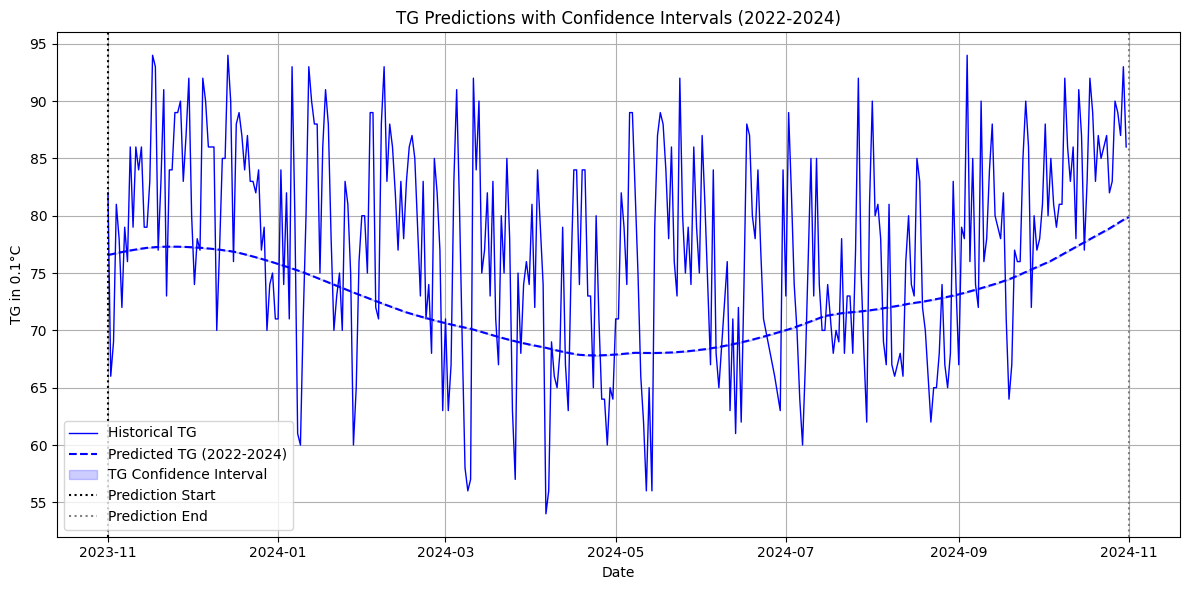

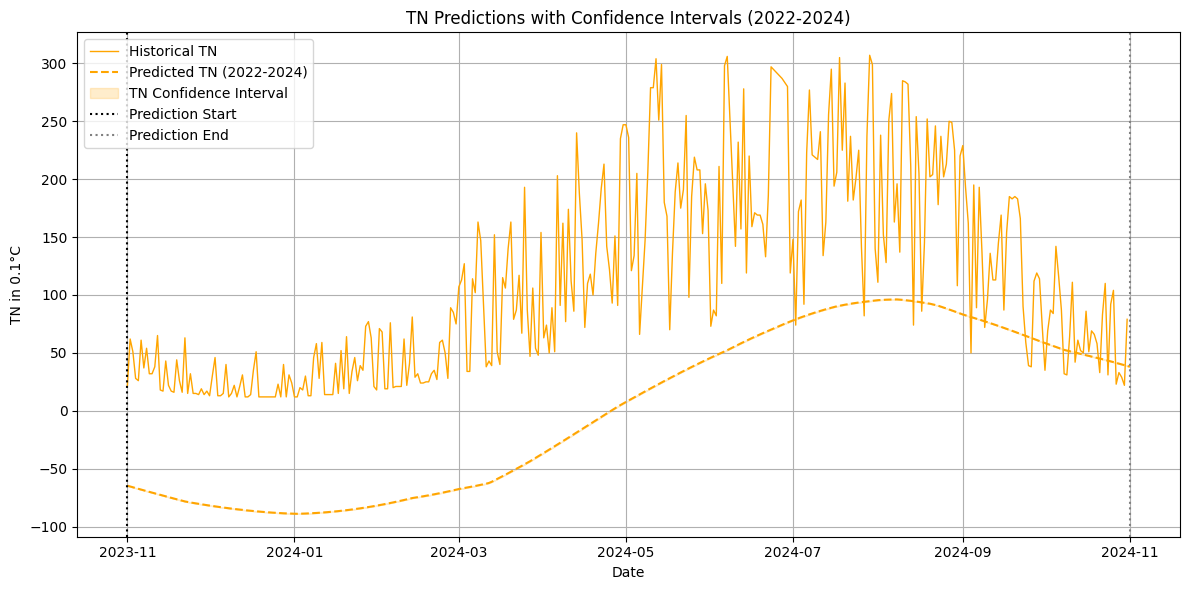

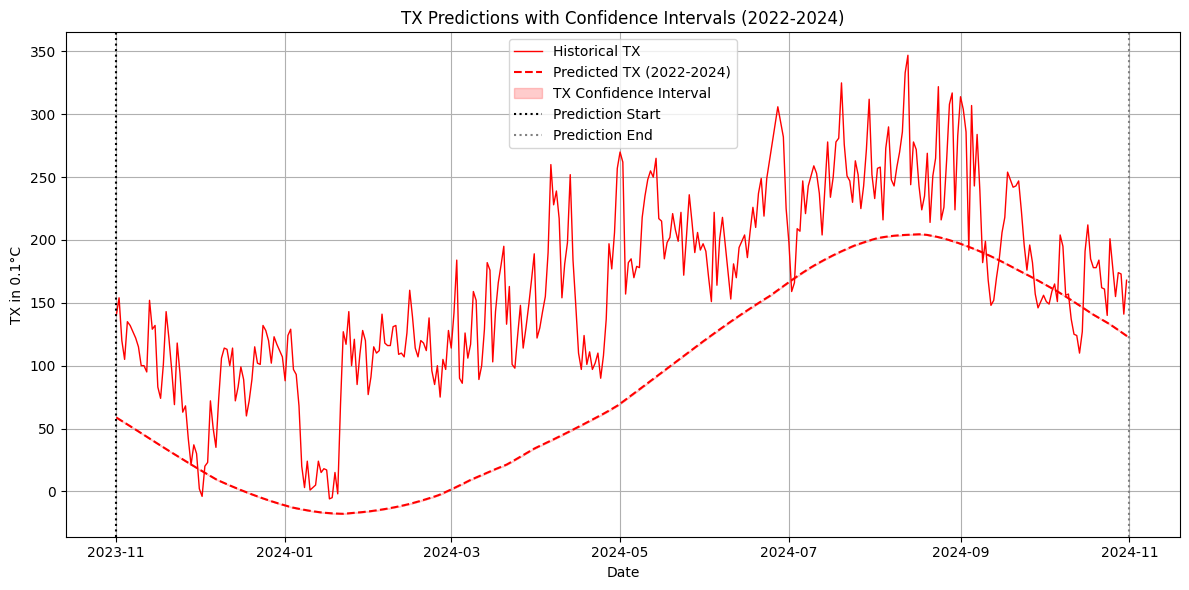

Error rate for TG between 2022 and 2023: 9.98%
Error rate for TN between 2022 and 2023: 210.41%
Error rate for TX between 2022 and 2023: 63.57%
Skipping TG due to invalid predicted values (<= 0).
Skipping TN due to invalid predicted values (<= 0).
Skipping TX due to invalid predicted values (<= 0).
chi-sq: {}
{'TG': np.float64(-84.61015909976024), 'TN': np.float64(0.1916180291019044), 'TX': np.float64(-0.5969958734113285)}


In [33]:
import pandas as pd
import numpy as np
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# File paths
file_tg_path = 'HU_SOUID121047.txt'
file_tn_path = 'QQ_SOUID210447.txt'
file_tx_path = 'TX_SOUID121046.txt'

# Function to load and process data
def load_and_process(file_path, temp_col, quality_col):
    with open(file_path, 'r') as file:
        lines = file.readlines()

    # Identify data start
    data_start_index = next(i for i, line in enumerate(lines) if "SOUID" in line and "DATE" in line) + 1

    # Extract relevant data
    data_lines = lines[data_start_index:]
    data = []
    for line in data_lines:
        parts = line.split(",")
        if len(parts) >= 4:
            data.append([parts[0].strip(), parts[1].strip(), parts[2].strip(), parts[3].strip()])

    # Create DataFrame
    columns = ["SOUID", "DATE", temp_col, quality_col]
    df = pd.DataFrame(data, columns=columns)

    # Convert to appropriate types
    df[temp_col] = pd.to_numeric(df[temp_col], errors='coerce')
    df[quality_col] = pd.to_numeric(df[quality_col], errors='coerce')

    # Filter valid data
    df = df[df[quality_col] == 0]
    df["DATE"] = pd.to_datetime(df["DATE"], format='%Y%m%d')

    # Filter data from 2020 onwards
    df = df[df["DATE"] >= "2023-11-01"]
    return df

# Load datasets
tg_data = load_and_process(file_tg_path, "TG", "Q_TG")
tn_data = load_and_process(file_tn_path, "TN", "Q_TN")
tx_data = load_and_process(file_tx_path, "TX", "Q_TX")

# Combine datasets
combined_data = pd.merge(tg_data[["DATE", "TG"]], tn_data[["DATE", "TN"]], on="DATE")
combined_data = pd.merge(combined_data, tx_data[["DATE", "TX"]], on="DATE")

# Prepare for MLP fitting
X = (combined_data["DATE"] - pd.Timestamp("2023-11-01")).dt.days.values.reshape(-1, 1)

# Adding periodic features
X_periodic = np.hstack([
    X,
    np.sin(2 * np.pi * X / 365.25),  # Annual cycle
    np.cos(2 * np.pi * X / 365.25)
])

# Scale features
scaler_X = StandardScaler()
scaler_y = StandardScaler()
X_scaled = scaler_X.fit_transform(X_periodic)

# Define prediction start and end dates
prediction_start = pd.Timestamp("2023-11-01")
prediction_end = pd.Timestamp("2024-11-01")
future_dates = pd.date_range(start=prediction_start, end=prediction_end)
X_future = (future_dates - pd.Timestamp("2024-11-01")).days.values.reshape(-1, 1)
X_future_periodic = np.hstack([
    X_future,
    np.sin(2 * np.pi * X_future / 365.25),
    np.cos(2 * np.pi * X_future / 365.25)
])
X_future_scaled = scaler_X.transform(X_future_periodic)

# Loop through each temperature variable
error_rates = {}
for variable, color in zip(["TG", "TN", "TX"], ["blue", "orange", "red"]):
    # Prepare data for the current variable
    y = combined_data[variable].values
    y_scaled = scaler_y.fit_transform(y.reshape(-1, 1)).ravel()

    # Train MLP
    mlp = MLPRegressor(hidden_layer_sizes=(50,), max_iter=5000, random_state=42)
    mlp.fit(X_scaled, y_scaled)

    # Historical predictions
    y_pred_scaled = mlp.predict(X_scaled)
    y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()

    # Residuals and error calculation
    residuals = y - scaler_y.inverse_transform(y_scaled.reshape(-1, 1)).ravel()
    std_dev = np.std(residuals)

    # Future predictions
    y_future_scaled = mlp.predict(X_future_scaled)
    y_future = scaler_y.inverse_transform(y_future_scaled.reshape(-1, 1)).ravel()

    # Upper and lower bounds
    upper_bound = y_future + std_dev
    lower_bound = y_future - std_dev

    # Calculate error rate between 2022 and 2024
    actual_data = combined_data[(combined_data["DATE"] >= prediction_start) & (combined_data["DATE"] <= prediction_end)]
    actual_values = actual_data[variable].values
    predicted_values = y_future[:len(actual_values)]

    # Avoid division by zero for error calculation
    valid_indices = actual_values != 0
    error_rate = np.mean(np.abs(actual_values[valid_indices] - predicted_values[valid_indices]) / actual_values[valid_indices]) * 100
    error_rates[variable] = error_rate


    # Create individual plots
    plt.figure(figsize=(12, 6))
    plt.plot(combined_data["DATE"], combined_data[variable], label=f"Historical {variable}", linestyle='-', linewidth=1, color=color)
    plt.plot(future_dates, y_future, label=f"Predicted {variable} (2022-2024)", linestyle='--', color=color)
    plt.fill_between(future_dates, lower_bound, upper_bound, color=color, alpha=0.2, label=f"{variable} Confidence Interval")
    plt.axvline(x=prediction_start, color="black", linestyle=":", label="Prediction Start")
    plt.axvline(x=prediction_end, color="grey", linestyle=":", label="Prediction End")
    plt.title(f"{variable} Predictions with Confidence Intervals (2022-2024)")
    plt.xlabel("Date")
    plt.ylabel(f"{variable} in 0.1°C")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Print error rates
for variable, error_rate in error_rates.items():
    print(f"Error rate for {variable} between 2022 and 2023: {error_rate:.2f}%")



from scipy.stats import chisquare

# Chi-square test results for each dataset
chi_square_results = {}

for variable in ["TG", "TN", "TX"]:
    # Observed values (2022-2024 actual data)
    actual_data = combined_data[(combined_data["DATE"] >= prediction_start) & (combined_data["DATE"] <= prediction_end)]
    observed = actual_data[variable].values

    # Predicted values (2022-2024 predictions)
    predicted = y_future[:len(observed)]

    # Ensure no zero or negative predicted values to avoid errors
    if np.any(predicted <= 0):
        print(f"Skipping {variable} due to invalid predicted values (<= 0).")
        continue

    # Normalize observed and predicted frequencies
    observed_normalized = observed / np.sum(observed)
    predicted_normalized = predicted / np.sum(predicted)

    # Chi-square test
    chi2_stat, p_value = chisquare(f_obs=observed_normalized, f_exp=predicted_normalized)
    chi_square_results[variable] = {"Chi2 Statistic": chi2_stat, "p-value": p_value}

# Display the results
print('chi-sq:',chi_square_results)

# R^2 Calculation
r_squared_results = {}

for variable in ["TG", "TN", "TX"]:
    # Observed values (2022-2024 actual data)
    actual_data = combined_data[(combined_data["DATE"] >= prediction_start) & (combined_data["DATE"] <= prediction_end)]
    observed = actual_data[variable].values

    # Predicted values (2022-2024 predictions)
    predicted = y_future[:len(observed)]

    # Calculate R^2
    ss_residual = np.sum((observed - predicted) ** 2)  # Residual sum of squares
    ss_total = np.sum((observed - np.mean(observed)) ** 2)  # Total sum of squares
    r_squared = 1 - (ss_residual / ss_total)
    r_squared_results[variable] = r_squared

# Display R^2 results
print(r_squared_results)
